# MDM (Market Direction Model) Backtest

Notebook này thực hiện backtest hệ thống MDM trên dữ liệu VNINDEX từ 2016-01-16 đến 2026-01-16.

## Các bước thực hiện:
1. Load và xử lý dữ liệu
2. Tính toán indicators
3. Chạy MDM Engine
4. Phân tích signals
5. Xem danh sách trades
6. So sánh với Buy & Hold

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import MDM modules
from strategies.mdm_classic import (
    DataLoader, 
    Indicators, 
    DistributionDayCounter,
    RallyAttemptTracker,
    FTDSignalDetector,
    StopLossChecker,
    PositionManager,
    MarketState,
    MDMEngine,
    PerformanceAnalyzer
)

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)

print("✅ Modules loaded successfully!")

✅ Modules loaded successfully!


In [2]:
# Load data
loader = DataLoader('vn30_price.csv')
df = loader.load(start_date='2015-01-01', end_date='2026-01-16')

print(f"📊 Data loaded: {len(df)} rows")
print(f"📅 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"💹 Price range: {df['close'].min():.2f} to {df['close'].max():.2f}")

df.head(10)

📊 Data loaded: 2756 rows
📅 Date range: 2015-01-05 00:00:00 to 2026-01-16 00:00:00
💹 Price range: 538.53 to 2096.76


,symbol,date,open,close,low,high,volume
0,VN30,2015-01-05,600.48,599.69,599.69,604.99,52052371.0
1,VN30,2015-01-06,594.37,606.37,593.46,606.45,57176551.0
2,VN30,2015-01-07,606.49,607.65,606.49,611.78,53995280.0
3,VN30,2015-01-08,607.52,606.85,605.37,609.85,36922317.0
4,VN30,2015-01-09,608.26,618.41,608.26,619.52,56993397.0
5,VN30,2015-01-12,618.04,615.73,615.49,624.18,81434802.0
6,VN30,2015-01-13,614.22,619.39,614.06,619.58,48778150.0
7,VN30,2015-01-14,620.56,616.84,611.90,621.75,48366670.0
8,VN30,2015-01-15,617.12,617.62,613.80,619.05,56436489.0
9,VN30,2015-01-16,616.89,614.72,613.40,617.52,46384030.0


## 2. Visualize VNINDEX Data

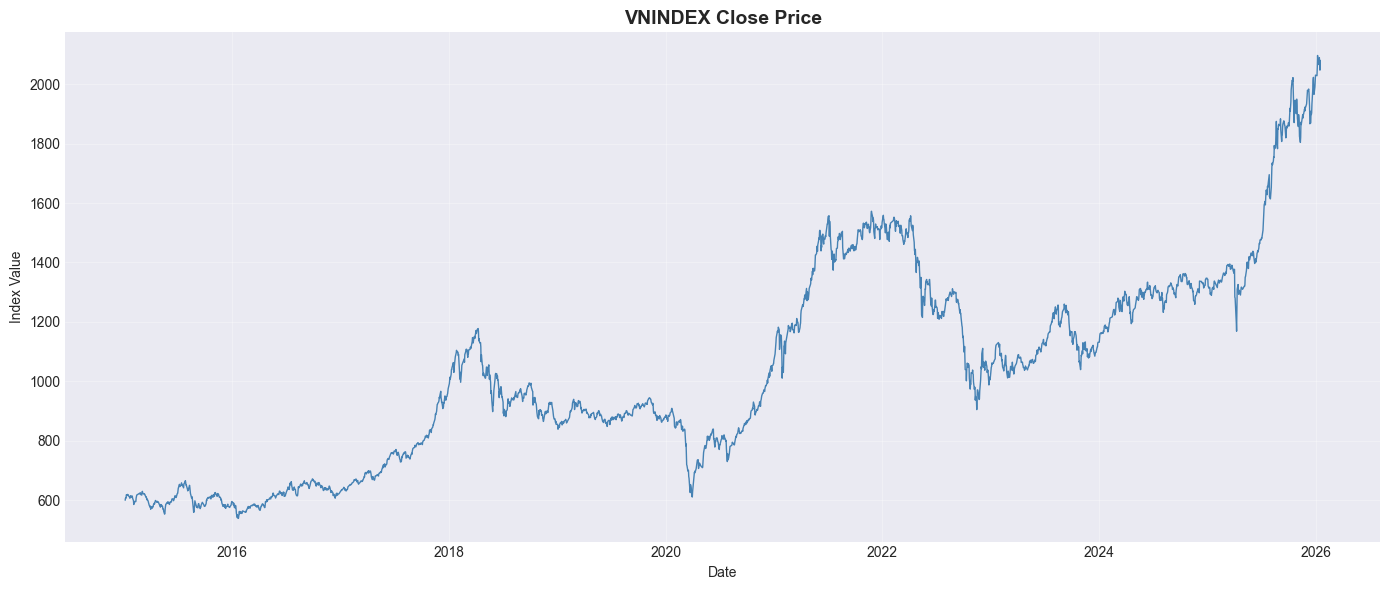

In [3]:
# Plot VNINDEX price
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['date'], df['close'], linewidth=1, color='steelblue')
ax.set_title('VNINDEX Close Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Run MDM Engine

In [4]:
# Initialize and run MDM Engine
engine = MDMEngine()
results = engine.run(df)

print("✅ MDM Engine completed!")
print(f"📊 Processed {len(results)} trading days")

# Summary
summary = engine.summary()
print(f"\n📈 Summary:")
print(f"  - Total Long Trades: {summary['total_long_trades']}")
print(f"  - Completed Long Trades: {summary['completed_long_trades']}")
print(f"  - Long Wins: {summary['long_wins']}")
print(f"  - Long PnL: {summary['long_pnl']*100:.2f}%")
print(f"  - Total Short Trades: {summary['total_short_trades']}")
print(f"  - Completed Short Trades: {summary['completed_short_trades']}")
print(f"  - Short Wins: {summary['short_wins']}")
print(f"  - Short PnL: {summary['short_pnl']*100:.2f}%")
print(f"  - Win Rate: {summary['win_rate']*100:.1f}%")
print(f"  - Total PnL: {summary['total_pnl']*100:.2f}%")

✅ MDM Engine completed!
📊 Processed 2756 trading days

📈 Summary:
  - Total Long Trades: 33
  - Completed Long Trades: 32
  - Long Wins: 10
  - Long PnL: 126.20%
  - Total Short Trades: 7
  - Completed Short Trades: 7
  - Short Wins: 1
  - Short PnL: -5.20%
  - Win Rate: 28.2%
  - Total PnL: 121.01%


## 4. View Signals

In [5]:
# Get all signals (FTD, actions)
signals = engine.get_signals()
print(f"📊 Total signals: {len(signals)}")

signals

📊 Total signals: 147


,date,close,state,action,rally_day,dd_count
1,2015-01-06,606.37,HOLDING,BUY at 606.37 (52WEEK),0,0
21,2015-02-03,585.47,CASH,SELL at 585.47 (52-Week Breakout Stop Loss (Cl...,0,4
36,2015-03-04,629.69,HOLDING,BUY at 629.69 (52WEEK),0,0
41,2015-03-11,619.27,CASH,SELL at 619.27 (52-Week Breakout Stop Loss (Cl...,0,1
86,2015-05-19,556.44,CASH,,1,0
...,...,...,...,...,...,...
2704,2025-11-04,1897.71,HOLDING,BUY at 1897.71 (MA50),0,0
2707,2025-11-07,1824.71,CASH,SELL at 1824.71 (Stop loss: 3.85% loss exceeds...,0,2
2713,2025-11-17,1893.54,HOLDING,BUY at 1893.54 (MA50),0,0
2715,2025-11-19,1886.20,CASH,SELL at 1886.20 (Break below MA50 (1895.16) wi...,0,1


In [6]:
# View FTD signals only
ftd_signals = results[results['is_ftd'] == True]
print(f"\n🎯 FTD Signals: {len(ftd_signals)}")

ftd_signals[['date', 'close', 'rally_day', 'state', 'action']]


🎯 FTD Signals: 40


,date,close,rally_day,state,action
1,2015-01-06,606.37,0,HOLDING,BUY at 606.37 (52WEEK)
36,2015-03-04,629.69,0,HOLDING,BUY at 629.69 (52WEEK)
118,2015-07-02,633.28,0,HOLDING,BUY at 633.28 (52WEEK)
187,2015-10-08,604.91,0,CASH,COVER at 604.91 (FTD signal)
430,2016-09-27,671.21,0,HOLDING,BUY at 671.21 (52WEEK)
549,2017-03-21,679.69,0,HOLDING,BUY at 679.69 (52WEEK)
590,2017-05-22,710.86,0,HOLDING,BUY at 710.86 (52WEEK)
837,2018-05-18,1022.21,12,CASH,COVER at 1022.21 (FTD signal)
847,2018-06-01,969.15,4,HOLDING,BUY at 969.15 ()
877,2018-07-13,899.45,6,HOLDING,BUY at 899.45 ()


In [7]:
# View Distribution Days
dd_days = results[results['is_dd'] == True]
print(f"\n⚠️ Distribution Days: {len(dd_days)}")

dd_days[['date', 'close', 'dd_type', 'dd_count', 'state', 'action']].head(20)


⚠️ Distribution Days: 232


,date,close,dd_type,dd_count,state,action
5,2015-01-12,615.73,1,1,HOLDING,
12,2015-01-21,606.53,1,2,HOLDING,
16,2015-01-27,609.98,1,3,HOLDING,
20,2015-02-02,598.46,1,4,HOLDING,
37,2015-03-05,625.25,1,1,HOLDING,
122,2015-07-08,645.67,1,1,HOLDING,
128,2015-07-16,649.06,1,2,HOLDING,
136,2015-07-28,659.60,1,3,HOLDING,
139,2015-07-31,647.36,1,4,HOLDING,
140,2015-08-03,636.92,1,5,WAITING_SELL,"WARNING: 5 DD reached, trigger at 632.93"


## 5. Trade List

In [8]:
# Get all trades
trades = engine.get_trades()
trades_df = engine.get_trade_df()

print(f"📝 Total trade records: {len(trades)}")
trades_df

📝 Total trade records: 79


,type,date,price,signal_type,reason,pnl
0,BUY,2015-01-06,606.37,52WEEK,NaN,NaN
1,SELL,2015-02-03,585.47,NaN,52-Week Breakout Stop Loss (Close < 0.99 * Day...,-0.034467
2,BUY,2015-03-04,629.69,52WEEK,NaN,NaN
3,SELL,2015-03-11,619.27,NaN,52-Week Breakout Stop Loss (Close < 0.99 * Day...,-0.016548
4,BUY,2015-07-02,633.28,52WEEK,NaN,NaN
5,SELL,2015-09-07,574.09,NaN,Trigger break → Open Short,-0.093466
6,SHORT,2015-09-07,574.09,NaN,NaN,NaN
7,COVER,2015-10-08,604.91,NaN,FTD signal,-0.053685
8,BUY,2016-09-27,671.21,52WEEK,NaN,NaN
9,SELL,2016-10-07,657.54,NaN,52-Week Breakout Stop Loss (Close < 0.99 * Day...,-0.020366


In [9]:
# Pair BUY and SELL trades
buy_trades = [t for t in trades if t['type'] == 'BUY']
sell_trades = [t for t in trades if t['type'] == 'SELL']

paired_trades = []
for i, (buy, sell) in enumerate(zip(buy_trades, sell_trades)):
    paired_trades.append({
        'Trade #': i + 1,
        'Buy Date': buy['date'].strftime('%Y-%m-%d'),
        'Buy Price': buy['price'],
        'Sell Date': sell['date'].strftime('%Y-%m-%d'),
        'Sell Price': sell['price'],
        'P&L (%)': f"{sell['pnl']*100:.2f}%",
        'Reason': sell['reason']
    })

paired_df = pd.DataFrame(paired_trades)
print("📊 Paired Trades:")
paired_df

📊 Paired Trades:


,Trade #,Buy Date,Buy Price,Sell Date,Sell Price,P&L (%),Reason
0,1,2015-01-06,606.37,2015-02-03,585.47,-3.45%,52-Week Breakout Stop Loss (Close < 0.99 * Day...
1,2,2015-03-04,629.69,2015-03-11,619.27,-1.65%,52-Week Breakout Stop Loss (Close < 0.99 * Day...
2,3,2015-07-02,633.28,2015-09-07,574.09,-9.35%,Trigger break → Open Short
3,4,2016-09-27,671.21,2016-10-07,657.54,-2.04%,52-Week Breakout Stop Loss (Close < 0.99 * Day...
4,5,2017-03-21,679.69,2017-04-17,669.31,-1.53%,52-Week Breakout Stop Loss (Close < 0.99 * Day...
5,6,2017-05-22,710.86,2018-03-07,1092.17,53.64%,Trigger break → Open Short
6,7,2018-06-01,969.15,2018-06-19,945.11,-2.48%,Closed below buy day low (948.69): 2.48% loss
7,8,2018-07-13,899.45,2018-10-11,920.02,2.29%,Break below MA50 (961.45) with high volume: -2...
8,9,2018-12-03,921.72,2018-12-17,901.41,-2.20%,Break below MA50 (907.56) with high volume: 2....
9,10,2019-02-12,888.33,2019-03-25,893.40,0.57%,Break below MA50 (895.73) with high volume: -0...


## 6. Performance Comparison: MDM vs Buy & Hold

In [10]:
# Performance analysis
analyzer = PerformanceAnalyzer(results, trades)

# Print detailed report
analyzer.print_report()

MDM PERFORMANCE REPORT

📊 BUY & HOLD BENCHMARK
----------------------------------------
  Start Price:      599.69
  End Price:        2,080.35
  Total Return:     246.90%
  Annualized:       11.94%
  Max Drawdown:     -48.14%

📈 MDM STRATEGY
----------------------------------------
  Total Return:     156.18%
  Annualized:       8.90%
  Max Drawdown:     -14.00%
  Trades:           32
  Wins/Losses:      10/22
  Win Rate:         31.25%
  Avg Win:          18.08%
  Avg Loss:         -2.48%

❌ MDM UNDERPERFORMS by 90.73%


In [11]:
# Comparison table
comparison = analyzer.compare()
comparison

,Metric,Buy & Hold,MDM Strategy
0,Total Return,246.90%,156.18%
1,Annualized Return,11.94%,8.90%
2,Max Drawdown,-48.14%,-14.00%
3,Number of Trades,N/A (always in),32
4,Win Rate,N/A,31.25%


## 7. Equity Curve Visualization

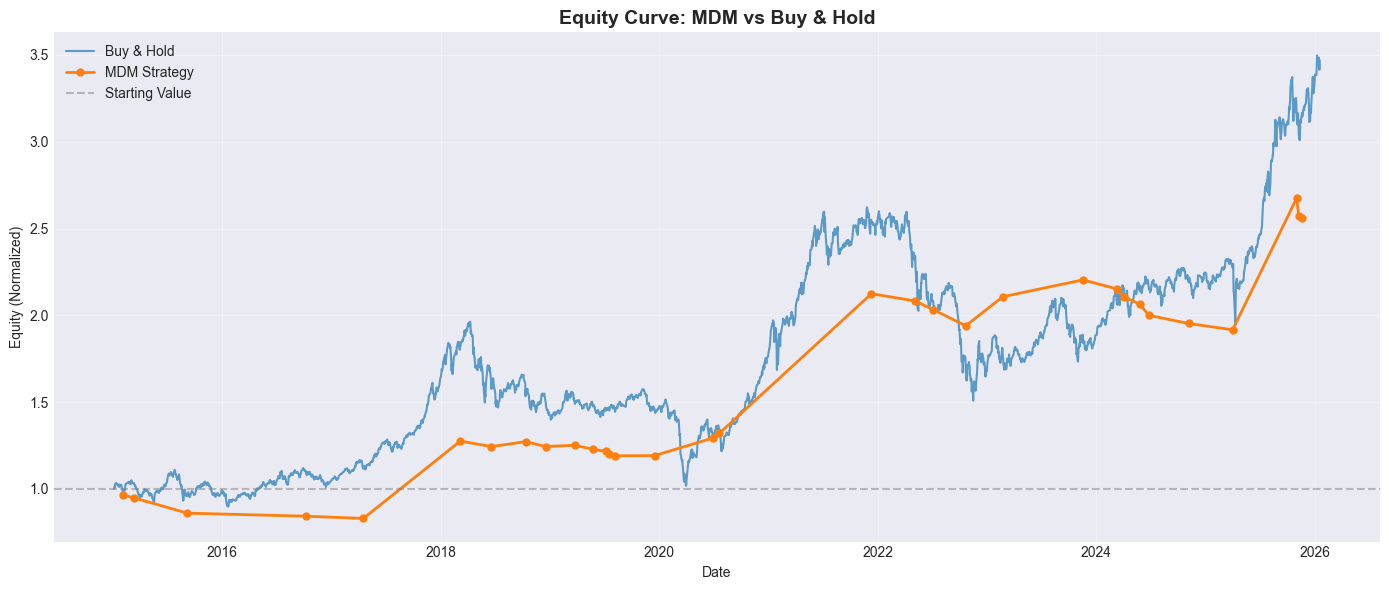

In [12]:
# Build equity curves
mdm_perf = analyzer.calculate_mdm_performance()
bh_perf = analyzer.calculate_buy_and_hold()

# Buy & Hold equity curve (normalized)
bh_equity = (results['close'] / results['close'].iloc[0])

# MDM equity from trade history
mdm_equity_history = mdm_perf.get('equity_history', [])

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

# Buy & Hold
ax.plot(results['date'], bh_equity, label='Buy & Hold', linewidth=1.5, alpha=0.7)

# MDM equity points
if mdm_equity_history:
    mdm_dates = [e['date'] for e in mdm_equity_history]
    mdm_values = [e['equity'] for e in mdm_equity_history]
    ax.plot(mdm_dates, mdm_values, 'o-', label='MDM Strategy', linewidth=2, markersize=5)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Starting Value')
ax.set_title('Equity Curve: MDM vs Buy & Hold', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Equity (Normalized)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Signal Visualization on Price Chart

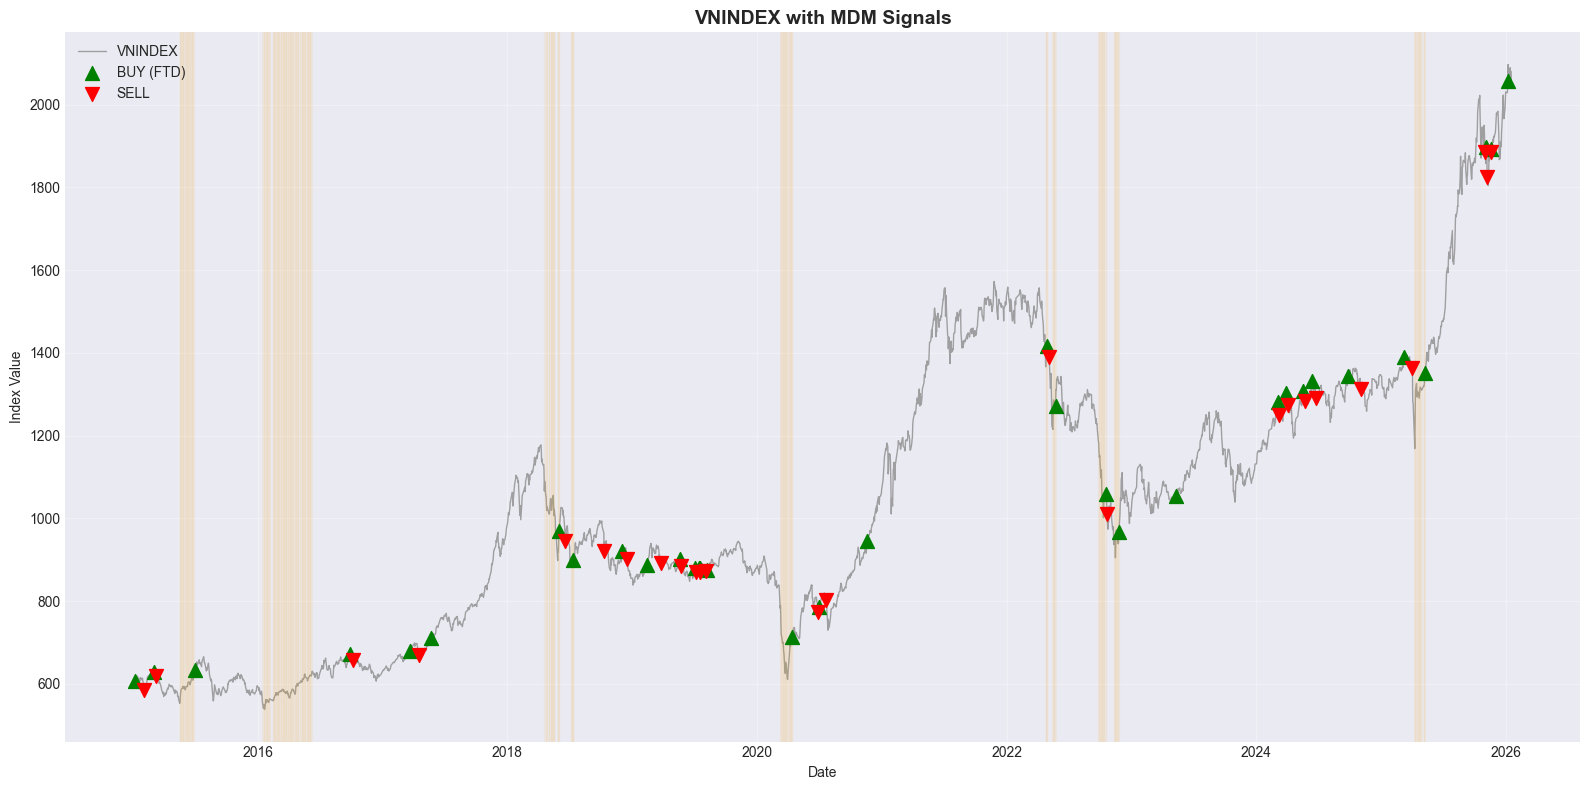

In [13]:
# Plot price with signals
fig, ax = plt.subplots(figsize=(16, 8))

# Price line
ax.plot(results['date'], results['close'], linewidth=1, color='gray', alpha=0.7, label='VNINDEX')

# Buy signals (FTD)
buy_signals = results[results['action'].str.contains('BUY', na=False)]
ax.scatter(buy_signals['date'], buy_signals['close'], 
          marker='^', s=100, c='green', label='BUY (FTD)', zorder=5)

# Sell signals
sell_signals = results[results['action'].str.contains('SELL', na=False)]
ax.scatter(sell_signals['date'], sell_signals['close'], 
          marker='v', s=100, c='red', label='SELL', zorder=5)

# Correction periods (shade)
in_correction = results[results['in_correction'] == True]
for idx, row in in_correction.iterrows():
    ax.axvline(x=row['date'], color='orange', alpha=0.05, linewidth=1)

ax.set_title('VNINDEX with MDM Signals', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Detailed State Transitions

In [14]:
# View state transitions
state_changes = results[results['action'] != '']
print(f"📊 State changes: {len(state_changes)}")
52
state_changes[['date', 'close', 'state', 'action', 'dd_count', 'rally_day']]

📊 State changes: 121


,date,close,state,action,dd_count,rally_day
1,2015-01-06,606.37,HOLDING,BUY at 606.37 (52WEEK),0,0
21,2015-02-03,585.47,CASH,SELL at 585.47 (52-Week Breakout Stop Loss (Cl...,4,0
36,2015-03-04,629.69,HOLDING,BUY at 629.69 (52WEEK),0,0
41,2015-03-11,619.27,CASH,SELL at 619.27 (52-Week Breakout Stop Loss (Cl...,1,0
118,2015-07-02,633.28,HOLDING,BUY at 633.28 (52WEEK),0,0
...,...,...,...,...,...,...
2704,2025-11-04,1897.71,HOLDING,BUY at 1897.71 (MA50),0,0
2707,2025-11-07,1824.71,CASH,SELL at 1824.71 (Stop loss: 3.85% loss exceeds...,2,0
2713,2025-11-17,1893.54,HOLDING,BUY at 1893.54 (MA50),0,0
2715,2025-11-19,1886.20,CASH,SELL at 1886.20 (Break below MA50 (1895.16) wi...,1,0


## 10. Conclusion

### Tóm tắt kết quả:
- So sánh hiệu suất MDM với chiến lược Buy & Hold
- Phân tích win rate và average P&L per trade
- Đánh giá khả năng tránh các đợt giảm mạnh (max drawdown)

In [15]:
# Final summary
print("=" * 60)
print("KẾT LUẬN")
print("=" * 60)

mdm = analyzer.calculate_mdm_performance()
bh = analyzer.calculate_buy_and_hold()

mdm_return = mdm.get('total_return', 0)
bh_return = bh.get('total_return', 0)

print(f"\n📈 Buy & Hold Return: {bh_return*100:.2f}%")
print(f"📈 MDM Return: {mdm_return*100:.2f}%")

if mdm_return > bh_return:
    print(f"\n✅ MDM VƯỢT TRỘI hơn Buy & Hold {(mdm_return - bh_return)*100:.2f}%")
else:
    print(f"\n⚠️ MDM THẤP HƠN Buy & Hold {(bh_return - mdm_return)*100:.2f}%")
    
print(f"\n📉 Max Drawdown:")
print(f"   Buy & Hold: {bh.get('max_drawdown_pct', 'N/A')}")
print(f"   MDM: {mdm.get('max_drawdown_pct', 'N/A')}")

print("\n" + "=" * 60)

KẾT LUẬN

📈 Buy & Hold Return: 246.90%
📈 MDM Return: 156.18%

⚠️ MDM THẤP HƠN Buy & Hold 90.73%

📉 Max Drawdown:
   Buy & Hold: -48.14%
   MDM: -14.00%

